<a href="https://colab.research.google.com/github/youngbean0519/Self-Project/blob/main/notebooks/06_textcnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!git clone https://github.com/youngbean0519/Self-Project.git

Cloning into 'Self-Project'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 80 (delta 26), reused 59 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 508.31 KiB | 2.52 MiB/s, done.
Resolving deltas: 100% (26/26), done.


In [3]:
import os
import sys

PROJECT_DIR = "/content/Self-Project"
SRC_DIR = os.path.join(PROJECT_DIR, "src")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

DATA_DIR = "/content/drive/MyDrive/26_KOTE/data"
ARTIFACT_DIR = "/content/drive/MyDrive/26_KOTE/artifacts/week6_textcnn"

os.makedirs(ARTIFACT_DIR, exist_ok=True)

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("ARTIFACT_DIR:", ARTIFACT_DIR)

PROJECT_DIR: /content/Self-Project
DATA_DIR: /content/drive/MyDrive/26_KOTE/data
ARTIFACT_DIR: /content/drive/MyDrive/26_KOTE/artifacts/week6_textcnn


In [4]:
!pip install -q sentencepiece

In [5]:
import random
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    f1_score,
    hamming_loss,
    average_precision_score
)

import sentencepiece as spm

In [6]:
import preprocessing.text as text_preprocessing
import preprocessing.labels as preprocessing_labels
import evaluation.metrics as metrics
import utils.labels as utils_labels

In [7]:
TRAIN_PATH = os.path.join(DATA_DIR, "train.tsv")
VAL_PATH = os.path.join(DATA_DIR, "val.tsv")
TEST_PATH = os.path.join(DATA_DIR, "test.tsv")

print(TRAIN_PATH)
print(VAL_PATH)
print(TEST_PATH)

/content/drive/MyDrive/26_KOTE/data/train.tsv
/content/drive/MyDrive/26_KOTE/data/val.tsv
/content/drive/MyDrive/26_KOTE/data/test.tsv


In [8]:
train_df = pd.read_csv(TRAIN_PATH, sep="\t", header=None, names=["id", "text", "labels"])
val_df = pd.read_csv(VAL_PATH, sep="\t", header=None, names=["id", "text", "labels"])
test_df = pd.read_csv(TEST_PATH, sep="\t", header=None, names=["id", "text", "labels"])

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print(train_df.columns)
train_df.head()

Train: (40000, 3)
Validation: (5000, 3)
Test: (5000, 3)
Index(['id', 'text', 'labels'], dtype='object')


,id,text,labels
0,39087,내가 톰행크스를 좋아하긴 했나보다... 초기 영화 빼고는 다 봤네.,"2,13,15,16,29,39"
1,30893,"정말 상상을 초월하는 무개념 진상들 상대하다 우울증, 공항장애 걸리는 공무원 많아요...","0,5,7,10,19,22,29,35,36,38"
2,45278,"새로운 세상과 조우한 자의 어린아이 같은 반응, 어쩌면 회복된 것은 눈이 아닌 순수...","1,2,7"
3,16398,미역은 원생생물계 산호초는 동물ㅇㅇ 아 미역이 바다의 새ㄱㅇㄱㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ,"9,15,20,23,26,28,29"
4,13653,네 맞습니다 플스는 역시 30프레임이 어울리죠 ㅎ,"1,2,8,9,11,13,15,16,28,29,32,40,42"


In [9]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
  print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA L4


In [12]:
def make_preprocessed_texts(df, normalize_repeat, remove_symbols):
  return df["text"].astype(str).apply(
      lambda text: text_preprocessing.preprocess_text(
          text,
          normalize_repeat=normalize_repeat,
          remove_symbols=remove_symbols
      )
  )

In [13]:
sample = train_df["text"].astype(str)

sample_repeat = make_preprocessed_texts(
    train_df,
    normalize_repeat=True,
    remove_symbols=False
)

sample_repeat_symbols = make_preprocessed_texts(
    train_df,
    normalize_repeat=True,
    remove_symbols=True
)

In [14]:
changed_symbols = (
    sample_repeat != sample_repeat_symbols
)

print("Total samples:", len(sample))
print("repeat -> repeat_symbols changed:", changed_symbols.sum())
print("Difference ratio:", changed_symbols.mean())
print("All identical:", sample_repeat.equals(sample_repeat_symbols))

Total samples: 40000
repeat -> repeat_symbols changed: 25198
Difference ratio: 0.62995
All identical: False


In [15]:
comparison_df = pd.DataFrame({
    "original": sample,
    "repeat": sample_repeat,
    "repeat_symbols": sample_repeat_symbols
})

comparison_df[changed_symbols].head(20)

,original,repeat,repeat_symbols
0,내가 톰행크스를 좋아하긴 했나보다... 초기 영화 빼고는 다 봤네.,내가 톰행크스를 좋아하긴 했나보다.. 초기 영화 빼고는 다 봤네.,내가 톰행크스를 좋아하긴 했나보다 초기 영화 빼고는 다 봤네
1,"정말 상상을 초월하는 무개념 진상들 상대하다 우울증, 공항장애 걸리는 공무원 많아요...","정말 상상을 초월하는 무개념 진상들 상대하다 우울증, 공항장애 걸리는 공무원 많아요...",정말 상상을 초월하는 무개념 진상들 상대하다 우울증 공항장애 걸리는 공무원 많아요 ...
2,"새로운 세상과 조우한 자의 어린아이 같은 반응, 어쩌면 회복된 것은 눈이 아닌 순수...","새로운 세상과 조우한 자의 어린아이 같은 반응, 어쩌면 회복된 것은 눈이 아닌 순수...",새로운 세상과 조우한 자의 어린아이 같은 반응 어쩌면 회복된 것은 눈이 아닌 순수함...
6,물갈이약 구매했어요...미미네에서 수조2개랑 여러가지 용품사면서 3~4번 주문했었는...,물갈이약 구매했어요..미미네에서 수조2개랑 여러가지 용품사면서 3~4번 주문했었는데...,물갈이약 구매했어요 미미네에서 수조2개랑 여러가지 용품사면서 3~4번 주문했었는데 ...
7,"십일조는 겨우60인데? 나머지 다 어디감? 혹시 엄마아빠 그랜져따로타고, 외식자주하...","십일조는 겨우60인데? 나머지 다 어디감? 혹시 엄마아빠 그랜져따로타고, 외식자주하...",십일조는 겨우60인데? 나머지 다 어디감? 혹시 엄마아빠 그랜져따로타고 외식자주하는...
8,90년 줘야 하는거 아닌가? 쓰레기같은 것들.,90년 줘야 하는거 아닌가? 쓰레기같은 것들.,90년 줘야 하는거 아닌가? 쓰레기같은 것들
10,스토리 담당만 붙여줬으면 갓작품 됬을텐데.....,스토리 담당만 붙여줬으면 갓작품 됬을텐데..,스토리 담당만 붙여줬으면 갓작품 됬을텐데
11,"솔직히 말씀드릴게요. 맛없습니다. 장어라서 단백질원이 필요해서 오징어,연어,고등어,...","솔직히 말씀드릴게요. 맛없습니다. 장어라서 단백질원이 필요해서 오징어,연어,고등어,...",솔직히 말씀드릴게요 맛없습니다 장어라서 단백질원이 필요해서 오징어 연어 고등어 쇠고...
13,진작살껄그랬어요~안사고 그냥 넘길려고했는데 아기가 눕기싫어하고 바운서도 이제 싫어해...,진작살껄그랬어요~안사고 그냥 넘길려고했는데 아기가 눕기싫어하고 바운서도 이제 싫어해...,진작살껄그랬어요~안사고 그냥 넘길려고했는데 아기가 눕기싫어하고 바운서도 이제 싫어해...
14,_ 원래 트위터는 배우는 재미가 쏠쏠함ㅋㅋ 일단 님 존재감은 확실히 심어주셨음ㅋㅋㅋ...,_ 원래 트위터는 배우는 재미가 쏠쏠함ㅋㅋ 일단 님 존재감은 확실히 심어주셨음ㅋㅋ ...,_ 원래 트위터는 배우는 재미가 쏠쏠함ㅋㅋ 일단 님 존재감은 확실히 심어주셨음ㅋㅋ ...


In [16]:
TFIDF_PARAMS = {
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_features": 50000,
    "sublinear_tf": True
}

tfidf_repeat = TfidfVectorizer(**TFIDF_PARAMS)
tfidf_repeat_symbols = TfidfVectorizer(**TFIDF_PARAMS)

X_repeat = tfidf_repeat.fit_transform(sample_repeat)
X_repeat_symbols = tfidf_repeat_symbols.fit_transform(sample_repeat_symbols)

print("repeat shape:", X_repeat.shape)
print("repeat_symbols shape:", X_repeat_symbols.shape)
print("Same vocabulary:", set(tfidf_repeat.vocabulary_) == set(tfidf_repeat_symbols.vocabulary_))

repeat shape: (40000, 50000)
repeat_symbols shape: (40000, 50000)
Same vocabulary: True


In [17]:
difference = X_repeat != X_repeat_symbols
print("Number of different TF-IDF values:", difference.nnz)

Number of different TF-IDF values: 0


## Preprocessing Verification

In Weeks 4 and 5, the `repeat` and `repeat_symbols`
preprocessing conditions produced identical results with
TF-IDF-based Logistic Regression and Linear SVM.

To verify whether this was caused by a preprocessing error,
the two preprocessing outputs were compared directly.

Symbol removal changed 25,198 out of 40,000 training samples.
However, the resulting TF-IDF vocabularies and feature matrices
were identical.

This indicates that the removed symbols were already ignored
during TF-IDF tokenization. Therefore, the identical results
observed in Weeks 4 and 5 were not caused by a preprocessing bug.

In [18]:
train_texts = make_preprocessed_texts(
    train_df,
    normalize_repeat=True,
    remove_symbols=False
)

val_texts = make_preprocessed_texts(
    val_df,
    normalize_repeat=True,
    remove_symbols=False
)

test_texts = make_preprocessed_texts(
    test_df,
    normalize_repeat=True,
    remove_symbols=False
)

print("Train:", len(train_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))

Train: 40000
Validation: 5000
Test: 5000


In [19]:
NUM_LABELS = 44

def make_multihot_labels(df, num_labels=44):
  targets = np.zeros((len(df), num_labels), dtype=np.float32)

  for i, label_string in enumerate(df["labels"].astype(str)):
    label_indices = [
        int(x.strip())
        for x in label_string.split(",")
        if x.strip()
    ]

    targets[i, label_indices] = 1.0

  return targets

y_train = make_multihot_labels(train_df)
y_val = make_multihot_labels(val_df)
y_test = make_multihot_labels(test_df)

print("Train:", y_train.shape)
print("Validation:", y_val.shape)
print("Test:", y_test.shape)

Train: (40000, 44)
Validation: (5000, 44)
Test: (5000, 44)


In [21]:
print("Original:")
print(train_df["labels"].iloc[0])

print("\nActive label indices:")
print(np.where(y_train[0] == 1)[0])

Original:
2,13,15,16,29,39

Active label indices:
[ 2 13 15 16 29 39]


In [22]:
TOKENIZER_DIR = os.path.join(ARTIFACT_DIR, "sentencepiece")

os.makedirs(TOKENIZER_DIR, exist_ok=True)

TRAIN_TEXT_PATH = os.path.join(TOKENIZER_DIR, "train_text.txt")

with open(TRAIN_TEXT_PATH, "w", encoding="utf-8") as f:
  for text in train_texts:
    text = str(text).replace("\n", " ").strip()
    if text:
      f.write(text + "\n")

print(TRAIN_TEXT_PATH)

/content/drive/MyDrive/26_KOTE/artifacts/week6_textcnn/sentencepiece/train_text.txt


In [24]:
SP_VOCAB_SIZE = 8000

SP_MODEL_PREFIX = os.path.join(TOKENIZER_DIR, "kote_sp")

spm.SentencePieceTrainer.train(
    input=TRAIN_TEXT_PATH,
    model_prefix=SP_MODEL_PREFIX,
    vocab_size=SP_VOCAB_SIZE,
    model_type="unigram",
    character_coverage=1.0,
    pad_id=0,
    unk_id=1,
    bos_id=-1,
    eos_id=-1
)

True

In [25]:
tokenizer = spm.SentencePieceProcessor()
tokenizer.load(SP_MODEL_PREFIX + ".model")

PAD_IDX = tokenizer.pad_id()
UNK_IDX = tokenizer.unk_id()

print("Vovabulary size:", tokenizer.get_piece_size())

print("PAD_IDX:", PAD_IDX)
print("UNK_IDX:", UNK_IDX)

Vovabulary size: 8000
PAD_IDX: 0
UNK_IDX: 1


In [26]:
for i in range(5):
  text = train_texts.iloc[i]
  tokens = tokenizer.encode(text, out_type=str)

  print("TEXT:")
  print(text)

  print("\nTOKENS:")
  print(tokens)

  print("-" * 80)

TEXT:
내가 톰행크스를 좋아하긴 했나보다.. 초기 영화 빼고는 다 봤네.

TOKENS:
['▁내가', '▁', '톰', '행', '크', '스', '를', '▁좋아', '하긴', '▁', '했나', '보다', '..', '▁초', '기', '▁영화', '▁빼고', '는', '▁다', '▁봤', '네', '.']
--------------------------------------------------------------------------------
TEXT:
정말 상상을 초월하는 무개념 진상들 상대하다 우울증, 공항장애 걸리는 공무원 많아요 ㅠ 생각보다 스트레스 심한 직업군이라는 생각입니다.

TOKENS:
['▁정말', '▁상상', '을', '▁초', '월', '하는', '▁무', '개', '념', '▁진상', '들', '▁상대', '하다', '▁우울증', ',', '▁', '공항', '장', '애', '▁걸리', '는', '▁공무원', '▁많아요', '▁ᅲ', '▁생각보다', '▁스트레스', '▁심한', '▁직업', '군', '이라는', '▁생각', '입니다', '.']
--------------------------------------------------------------------------------
TEXT:
새로운 세상과 조우한 자의 어린아이 같은 반응, 어쩌면 회복된 것은 눈이 아닌 순수함일지도 모르겠습니다. 그걸 가능케 한 사랑에 경의를 표합니다.

TOKENS:
['▁새로운', '▁세상', '과', '▁조', '우', '한', '▁자', '의', '▁어린', '아이', '▁같은', '▁반응', ',', '▁어쩌', '면', '▁회복', '된', '▁것은', '▁눈이', '▁아닌', '▁순수', '함', '일', '지도', '▁모르겠', '습니다', '.', '▁그걸', '▁가능', '케', '▁한', '▁사랑에', '▁경', '의', '를', '▁표', '합니다', '.']
----------------------------

In [27]:
def calculate_unk_ratio(texts, tokenizer):
  total_tokens = 0
  unk_tokens = 0

  for text in texts:
    ids = tokenizer.encode(str(text), out_type=int)
    total_tokens += len(ids)
    unk_tokens += sum(
        token_id == UNK_IDX
        for token_id in ids
    )

  if total_tokens == 0:
    return 0.0

  return unk_tokens / total_tokens

train_unk_ratio = calculate_unk_ratio(train_texts, tokenizer)
val_unk_ratio = calculate_unk_ratio(val_texts, tokenizer)
test_unk_ratio = calculate_unk_ratio(test_texts, tokenizer)

print("Train UNK ratio:", train_unk_ratio)
print("Validation UNK ratio:", val_unk_ratio)
print("Test UNK ratio:", test_unk_ratio)

Train UNK ratio: 0.0
Validation UNK ratio: 0.0003258152029363264
Test UNK ratio: 0.0004467458625241141


In [28]:
train_lengths = train_texts.apply(
    lambda text: len(tokenizer.encode(str(text), out_type=int))
)

print(train_lengths.describe())

print("95 percentile:", np.percentile(train_lengths, 95))
print("99 percentile:", np.percentile(train_lengths, 99))

count    40000.000000
mean        29.266725
std         22.665082
min          1.000000
25%         14.000000
50%         22.000000
75%         37.000000
max        216.000000
Name: text, dtype: float64
95 percentile: 73.0
99 percentile: 116.0


In [29]:
p99 = int(np.percentile(train_lengths, 99))

MAX_LEN = int(np.ceil(p99 / 8) * 8)

truncated_count = (train_lengths > MAX_LEN).sum()
truncated_ratio = truncated_count / len(train_lengths)

print("99 percentile:", p99)
print("MAX_LEN:", MAX_LEN)
print("Truncated samples:", truncated_count)
print("Truncated ratio:", truncated_ratio)

99 percentile: 116
MAX_LEN: 120
Truncated samples: 338
Truncated ratio: 0.00845


In [30]:
class KOTEDataset(Dataset):

  def __init__(self, texts, labels, tokenizer, max_len):
    self.texts = texts.reset_index(drop=True)
    self.labels = labels
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, idx):
    text = str(self.texts.iloc[idx])
    input_ids = self.tokenizer.encode(text, out_type=int)
    input_ids = input_ids[:self.max_len]

    padding_length = self.max_len - len(input_ids)
    if padding_length > 0:
      input_ids += [PAD_IDX] * padding_length

    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "labels": torch.tensor(self.labels[idx], dtype=torch.float32)
    }

In [31]:
train_dataset = KOTEDataset(
    train_texts,
    y_train,
    tokenizer,
    MAX_LEN
)

val_dataset = KOTEDataset(
    val_texts,
    y_val,
    tokenizer,
    MAX_LEN
)

test_dataset = KOTEDataset(
    test_texts,
    y_test,
    tokenizer,
    MAX_LEN
)

print(
    len(train_dataset),
    len(val_dataset),
    len(test_dataset)
)

40000 5000 5000


In [32]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [33]:
batch = next(
    iter(train_loader)
)

print(
    "input_ids:",
    batch["input_ids"].shape
)

print(
    "labels:",
    batch["labels"].shape
)

input_ids: torch.Size([128, 120])
labels: torch.Size([128, 44])


In [34]:
class TextCNN(nn.Module):

  def __init__(
    self,
    vocab_size,
    embed_dim,
    num_filters,
    kernel_sizes,
    num_labels,
    dropout,
    padding_idx
  ):
    super().__init__()

    self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
    self.convs = nn.ModuleList([
        nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
        for k in kernel_sizes
    ])
    self.dropout = nn.Dropout(dropout)
    self.classifier = nn.Linear(num_filters * len(kernel_sizes), num_labels)

  def forward(self, input_ids):
    x = self.embedding(input_ids)
    x = x.transpose(1, 2)
    pooled_outputs=  []

    for conv in self.convs:
      conv_output = torch.relu(conv(x))
      pooled = torch.max(conv_output, dim=2).values
      pooled_outputs.append(pooled)

    x = torch.cat(pooled_outputs, dim=1)
    x = self.dropout(x)
    logits = self.classifier(x)

    return logits

In [35]:
EMBED_DIM = 200
NUM_FILTERS = 128
KERNEL_SIZES = [2, 3, 4, 5]
DROPOUT = 0.3
LEARNING_RATE = 1e-3

In [36]:
model = TextCNN(
    vocab_size=tokenizer.get_piece_size(),
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    num_labels=NUM_LABELS,
    dropout=DROPOUT,
    padding_idx=PAD_IDX
).to(device)

print(model)

TextCNN(
  (embedding): Embedding(8000, 200, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(200, 128, kernel_size=(2,), stride=(1,))
    (1): Conv1d(200, 128, kernel_size=(3,), stride=(1,))
    (2): Conv1d(200, 128, kernel_size=(4,), stride=(1,))
    (3): Conv1d(200, 128, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=512, out_features=44, bias=True)
)


In [37]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

In [38]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
  model.train()
  total_loss = 0.0
  for batch in dataloader:
    input_ids = batch["input_ids"].to(device)
    labels = batch["labels"].to(device)
    optimizer.zero_grad()
    logits = model(input_ids)
    loss = criterion(logits, labels)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    total_loss += loss.item()

  return total_loss / len(dataloader)

In [43]:
def predict(model, dataloader, device):
  model.eval()
  probabilities = []
  labels = []
  with torch.no_grad():
    for batch in dataloader:
      input_ids = batch["input_ids"].to(device)
      logits = model(input_ids)
      probs = torch.sigmoid(logits)
      probabilities.append(probs.cpu().numpy())
      labels.append(batch["labels"].numpy())

  return np.vstack(probabilities), np.vstack(labels)

In [44]:
def evaluate_multilabel(y_true, y_prob, threshold):
  y_pred = (y_prob >= threshold).astype(int)
  micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
  macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
  hamming = hamming_loss(y_true, y_pred)
  pr_auc_micro = average_precision_score(y_true, y_prob, average="micro")
  pr_auc_macro = average_precision_score(y_true, y_prob, average="macro")

  return {
      "threshold": threshold,
      "micro_f1": micro_f1,
      "macro_f1": macro_f1,
      "hamming": hamming,
      "pr_auc_micro": pr_auc_micro,
      "pr_auc_macro": pr_auc_macro
  }

In [45]:
THRESHOLDS = np.arange(0.10, 0.61, 0.05)

def find_best_threshold(y_true, y_prob):
  results = []
  for threshold in THRESHOLDS:
    result = evaluate_multilabel(y_true, y_prob, threshold)
    results.append(result)

  results_df = pd.DataFrame(results)
  best_index = results_df["micro_f1"].idxmax()
  best_result = results_df.loc[best_index]

  return results_df, best_result

In [47]:
MAX_EPOCHS = 15
PATIENCE = 3

best_micro_f1 = -1.0
best_epoch = 0
patience_counter = 0

history = []

BEST_MODEL_PATH = os.path.join(ARTIFACT_DIR, "textcnn_best.pt")

start_time = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
  train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
  val_probs, val_labels = predict(model, val_loader, device)

  _, best_result = find_best_threshold(val_labels, val_probs)

  current_micro_f1 = best_result["micro_f1"]

  history.append({
      "epoch": epoch,
      "train_loss": train_loss,
      "threshold": best_result["threshold"],
      "micro_f1": best_result["micro_f1"],
      "macro_f1": best_result["macro_f1"],
      "hamming_loss": best_result["hamming"],
      "pr_auc_micro": best_result["pr_auc_micro"],
      "pr_auc_macro": best_result["pr_auc_macro"]
  })

  print(
      f"Epoch {epoch:02d} | "
      f"Loss: {train_loss:.4f} | "
      f"Threshold: "
      f"{best_result['threshold']:.2f} | "
      f"Micro F1: "
      f"{best_result['micro_f1']:.4f} | "
      f"Macro F1: "
      f"{best_result['macro_f1']:.4f}"
  )

  if current_micro_f1 > best_micro_f1:
    best_micro_f1 = current_micro_f1
    best_epoch = epoch
    patience_counter = 0
    torch.save(model.state_dict(), BEST_MODEL_PATH)
  else:
    patience_counter += 1
    if patience_counter >= PATIENCE:
      print("\nEarly stopping.")
      break

training_time = time.time() - start_time
print("\nBest epoch:", best_epoch)
print("Best validation Micro F1:", best_micro_f1)
print("Training time:", training_time)

Epoch 01 | Loss: 0.3534 | Threshold: 0.25 | Micro F1: 0.5220 | Macro F1: 0.3710
Epoch 02 | Loss: 0.3375 | Threshold: 0.25 | Micro F1: 0.5311 | Macro F1: 0.3922
Epoch 03 | Loss: 0.3242 | Threshold: 0.25 | Micro F1: 0.5356 | Macro F1: 0.3899
Epoch 04 | Loss: 0.3121 | Threshold: 0.25 | Micro F1: 0.5361 | Macro F1: 0.3969
Epoch 05 | Loss: 0.3014 | Threshold: 0.25 | Micro F1: 0.5387 | Macro F1: 0.4085
Epoch 06 | Loss: 0.2918 | Threshold: 0.25 | Micro F1: 0.5369 | Macro F1: 0.4125
Epoch 07 | Loss: 0.2832 | Threshold: 0.25 | Micro F1: 0.5400 | Macro F1: 0.4184
Epoch 08 | Loss: 0.2752 | Threshold: 0.25 | Micro F1: 0.5369 | Macro F1: 0.4147
Epoch 09 | Loss: 0.2685 | Threshold: 0.20 | Micro F1: 0.5343 | Macro F1: 0.4200
Epoch 10 | Loss: 0.2621 | Threshold: 0.25 | Micro F1: 0.5321 | Macro F1: 0.4129

Early stopping.

Best epoch: 7
Best validation Micro F1: 0.5400495646045063
Training time: 53.339391469955444


In [48]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

<All keys matched successfully>

In [50]:
val_probs, val_labels = predict(model, val_loader, device)

threshold_results, best_val_result = find_best_threshold(val_labels, val_probs)

threshold_results

,threshold,micro_f1,macro_f1,hamming,pr_auc_micro,pr_auc_macro
0,0.10,0.488939,0.415502,0.307786,0.56198,0.420038
1,0.15,0.521299,0.431262,0.243905,0.56198,0.420038
2,0.20,0.535664,0.427313,0.207223,0.56198,0.420038
3,0.25,0.540050,0.418445,0.183909,0.56198,0.420038
4,0.30,0.534092,0.401372,0.169805,0.56198,0.420038
5,0.35,0.523426,0.380942,0.160577,0.56198,0.420038
6,0.40,0.509285,0.357998,0.154464,0.56198,0.420038
7,0.45,0.489438,0.332316,0.151286,0.56198,0.420038
8,0.50,0.465169,0.305789,0.149886,0.56198,0.420038
9,0.55,0.438209,0.279051,0.149786,0.56198,0.420038


In [51]:
print("Best threshold:", best_val_result["threshold"])
print("Micro F1:", best_val_result["micro_f1"])
print("Macro F1:", best_val_result["macro_f1"])
print("Hamming loss:", best_val_result["hamming"])
print("PR AUC (micro):", best_val_result["pr_auc_micro"])
print("PR AUC (macro):", best_val_result["pr_auc_macro"])

Best threshold: 0.25000000000000006
Micro F1: 0.5400495646045063
Macro F1: 0.41844478056935763
Hamming loss: 0.1839090909090909
PR AUC (micro): 0.5619804909673514
PR AUC (macro): 0.4200380403529318


In [52]:
history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,threshold,micro_f1,macro_f1,hamming_loss,pr_auc_micro,pr_auc_macro
0,1,0.353370,0.25,0.521990,0.370993,0.194205,0.536294,0.392960
1,2,0.337480,0.25,0.531109,0.392166,0.191491,0.547854,0.404817
2,3,0.324185,0.25,0.535641,0.389875,0.183764,0.553132,0.408029
3,4,0.312065,0.25,0.536113,0.396862,0.181882,0.554920,0.413517
4,5,0.301393,0.25,0.538718,0.408454,0.186400,0.560096,0.417216
5,6,0.291787,0.25,0.536856,0.412481,0.189723,0.559395,0.418057
6,7,0.283155,0.25,0.540050,0.418445,0.183909,0.561980,0.420038
7,8,0.275249,0.25,0.536941,0.414695,0.183182,0.558754,0.419692
8,9,0.268508,0.20,0.534272,0.420047,0.194636,0.557777,0.418360
9,10,0.262089,0.25,0.532103,0.412868,0.181623,0.555227,0.417341


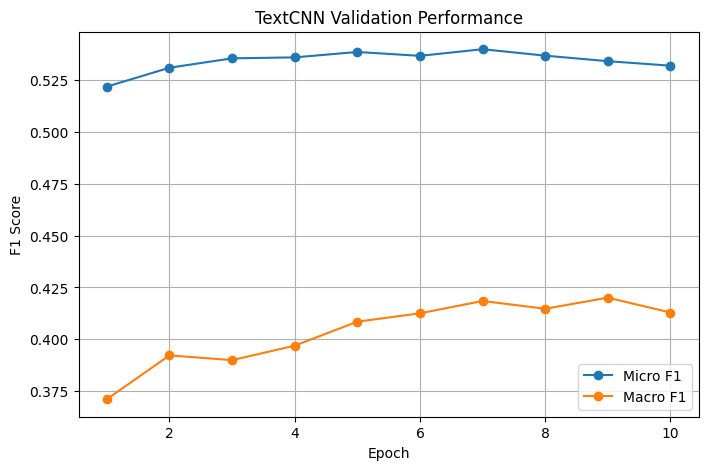

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["micro_f1"],
    marker="o",
    label="Micro F1"
)

plt.plot(
    history_df["epoch"],
    history_df["macro_f1"],
    marker="o",
    label="Macro F1"
)

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("TextCNN Validation Performance")

plt.legend()
plt.grid()
plt.show()

In [60]:
LABEL_NAMES = utils_labels.LABELS

print(len(LABEL_NAMES))
print(LABEL_NAMES[:10])

44
['불평/불만', '환영/호의', '감동/감탄', '지긋지긋', '고마움', '슬픔', '화남/분노', '존경', '기대감', '우쭐댐/무시함']


In [63]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

best_threshold = float(best_val_result["threshold"])
val_pred = (val_probs >= best_threshold).astype(int)

label_precision = precision_score(val_labels, val_pred, average=None, zero_division=0)
label_recall = recall_score(val_labels, val_pred, average=None, zero_division=0)
label_f1 = f1_score(val_labels, val_pred, average=None, zero_division=0)

labelwise_df = pd.DataFrame({
    "label_id": np.arange(NUM_LABELS),
    "label": LABEL_NAMES,
    "support": val_labels.sum(axis=0).astype(int),
    "precision": label_precision,
    "recall": label_recall,
    "f1": label_f1
})

labelwise_df.sort_values("f1", ascending=True).reset_index(drop=True)



,label_id,label,support,precision,recall,f1
0,30,죄책감,89,0.000000,0.000000,0.000000
1,17,부끄러움,286,0.054545,0.010490,0.017595
2,25,패배/자기혐오,183,0.153846,0.010929,0.020408
3,18,공포/무서움,134,0.400000,0.014925,0.028777
4,26,귀찮음,312,0.280899,0.080128,0.124688
5,36,서러움,234,0.250000,0.111111,0.153846
6,11,비장함,399,0.353591,0.160401,0.220690
7,35,부담/안_내킴,578,0.189781,0.269896,0.222857
8,19,절망,455,0.317726,0.208791,0.251989
9,27,힘듦/지침,477,0.310905,0.280922,0.295154
